In [ ]:
pip install torch torch-geometric pygod matplotlib seaborn pandas networkx

In [ ]:
import torch
import torch_geometric

# FIX: Allow PyTorch to load PyG internal classes
torch.serialization.add_safe_globals([
    torch_geometric.data.storage.GlobalStorage,
    torch_geometric.data.storage.NodeStorage,
    torch_geometric.data.storage.EdgeStorage,
    torch_geometric.data.storage.BaseStorage
])

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import roc_auc_score
from torch_geometric.nn import GCNConv
from torch_geometric.utils import negative_sampling
import torch_geometric
from pygod.utils import load_data

import warnings
from sklearn.decomposition import PCA
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_curve, auc as curve_auc
from scipy.stats import ks_2samp

warnings.filterwarnings('ignore')


# 1. FIX: PyTorch 2.6+ Security
torch.serialization.add_safe_globals([
    torch_geometric.data.storage.GlobalStorage,
    torch_geometric.data.storage.NodeStorage,
    torch_geometric.data.storage.EdgeStorage,
    torch_geometric.data.storage.BaseStorage
])

# 2. DEVICE SETUP
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 3. LOAD & FIX DATASET
print("--- Loading Reddit Dataset ---")
data = load_data('reddit')

# --- FIXING THE MISSING 's' ATTRIBUTE ---
if not hasattr(data, 's'):
    print("Attribute 's' not found. Extracting political leaning from features...")
    # In the FairGAD benchmark, the sensitive attribute is often the 1st feature
    # We binarize it: 0 for values <= median, 1 for values > median
    s_values = data.x[:, 0]
    median_val = torch.median(s_values)
    data.s = (s_values > median_val).long()
else:
    # Ensure it's in the correct format
    data.s = data.s.long()

data = data.to(device)
print(f"Nodes: {data.num_nodes} | Edges: {data.num_edges}")
print(f"Sensitive Groups: {torch.unique(data.s).tolist()} (0=Left, 1=Right)")

# 4. FAIR MODEL
class FairDOMINANT(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super(FairDOMINANT, self).__init__()
        self.enc = GCNConv(in_channels, hidden_channels)
        self.attr_dec = GCNConv(hidden_channels, in_channels)

    def forward(self, x, edge_index):
        h = F.relu(self.enc(x, edge_index))
        x_hat = self.attr_dec(h, edge_index)
        return x_hat, h

# 5. FAIRNESS METRICS (AUC, SP, EO)
def evaluate(y_true, scores, s):
    y_true = y_true.cpu().numpy()
    scores = scores.cpu().numpy()
    s = s.cpu().numpy()

    auc = roc_auc_score(y_true, scores)

    # Threshold top 10% as anomalies
    thresh = np.percentile(scores, 90)
    y_pred = (scores > thresh).astype(int)

    # Statistical Parity (SP)
    sp = abs(y_pred[s == 0].mean() - y_pred[s == 1].mean())

    # Equal Opportunity (EO)
    tpr0 = np.sum((y_pred==1)&(y_true==1)&(s==0)) / (np.sum((y_true==1)&(s==0)) + 1e-7)
    tpr1 = np.sum((y_pred==1)&(y_true==1)&(s==1)) / (np.sum((y_true==1)&(s==1)) + 1e-7)
    eo = abs(tpr0 - tpr1)

    return auc, sp, eo

# 6. TRAINING
model = FairDOMINANT(data.x.shape[1], 64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
lambda_f = 0.4 # Adjust for fairness

print("\nTraining...")
for epoch in range(1, 51):
    model.train()
    optimizer.zero_grad()

    x_hat, h = model(data.x, data.edge_index)

    # Loss 1: Attribute Reconstruction (MSE)
    loss_attr = F.mse_loss(x_hat, data.x, reduction='none').mean(dim=1)

    # Loss 2: Structural Reconstruction (sampled for memory)
    pos_idx = data.edge_index
    neg_idx = negative_sampling(pos_idx, num_nodes=data.num_nodes, num_neg_samples=pos_idx.size(1))
    pos_s = (h[pos_idx[0]] * h[pos_idx[1]]).sum(dim=1)
    neg_s = (h[neg_idx[0]] * h[neg_idx[1]]).sum(dim=1)
    loss_struct = F.binary_cross_entropy_with_logits(pos_s, torch.ones_like(pos_s)) + \
                  F.binary_cross_entropy_with_logits(neg_s, torch.zeros_like(neg_s))

    # Loss 3: Fairness Penalty (Statistical Parity)
    # We penalize the difference in reconstruction error between groups
    err_0 = loss_attr[data.s == 0].mean()
    err_1 = loss_attr[data.s == 1].mean()
    loss_fair = torch.abs(err_0 - err_1)

    total_loss = loss_attr.mean() + loss_struct + (lambda_f * loss_fair)
    total_loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        model.eval()
        with torch.no_grad():
            x_h, _ = model(data.x, data.edge_index)
            scores = torch.mean((x_h - data.x)**2, dim=1)
            auc, sp, eo = evaluate(data.y, scores, data.s)
            print(f"Epoch {epoch:02d} | AUC: {auc:.4f} | SP: {sp:.4f} | EO: {eo:.4f}")

--- Loading Reddit Dataset ---
Attribute 's' not found. Extracting political leaning from features...
Nodes: 10984 | Edges: 168016
Sensitive Groups: [0, 1] (0=Left, 1=Right)

Training...
Epoch 10 | AUC: 0.4934 | SP: 0.0097 | EO: 0.1362
Epoch 20 | AUC: 0.5812 | SP: 0.0013 | EO: 0.1553
Epoch 30 | AUC: 0.5362 | SP: 0.0064 | EO: 0.1176
Epoch 40 | AUC: 0.5619 | SP: 0.0069 | EO: 0.1206
Epoch 50 | AUC: 0.5590 | SP: 0.0158 | EO: 0.1377


In [ ]:
print(f"Nodes: {data.num_nodes}")
print(f"Edges: {data.num_edges}")
print(f"Features: {data.x.shape[1]}")
print(f"Anomaly Rate: {(data.y.sum() / data.num_nodes) * 100:.2f}%")

Nodes: 10984
Edges: 168016
Features: 64
Anomaly Rate: 3.33%


--- Finalizing Research EDA ---


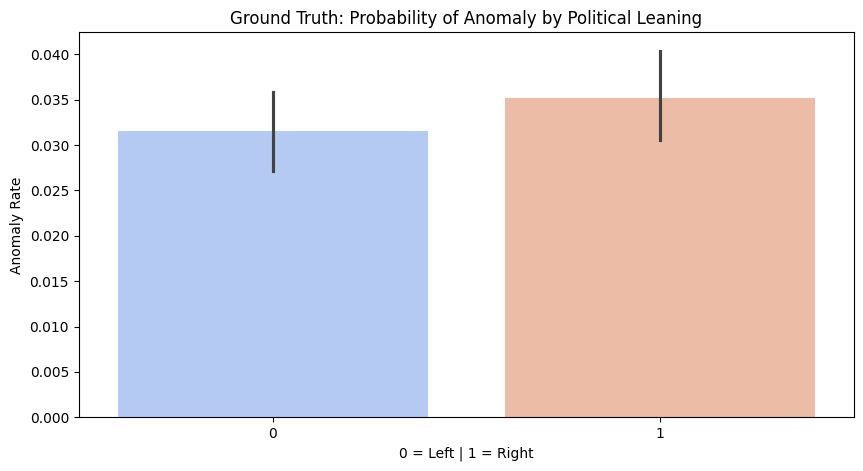

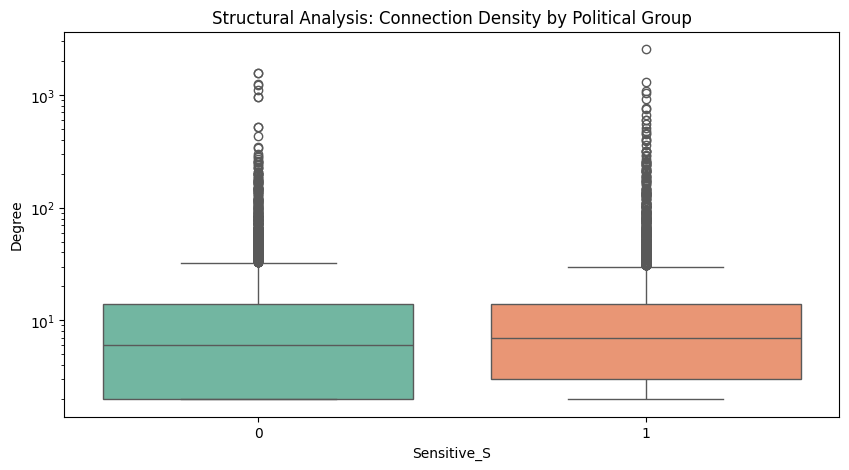

Homophily Ratio: 0.6676


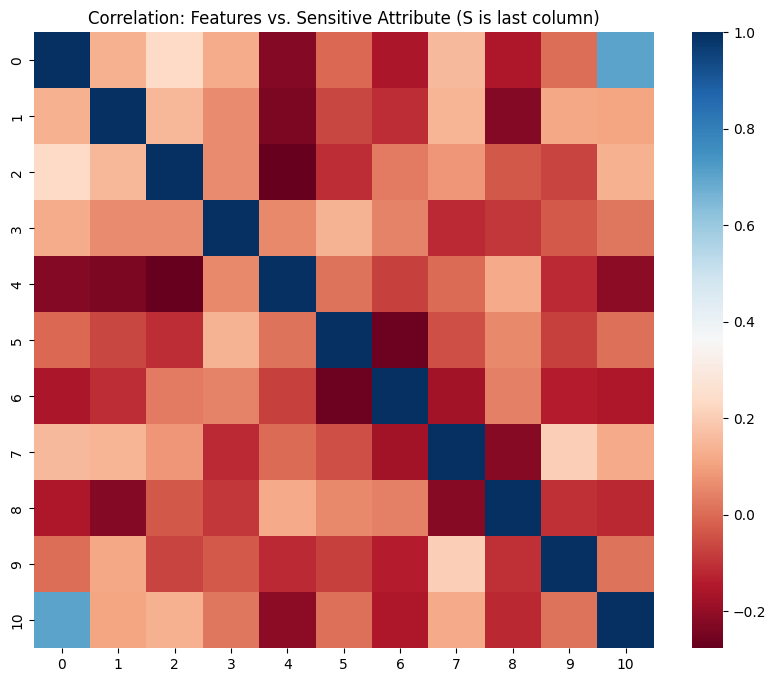

In [ ]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.utils import degree

# Assuming 'data' is already loaded from the previous steps
# 1. CONVERT DATA TO PANDAS FOR ANALYSIS
df = pd.DataFrame({
    'Sensitive_S': data.s.cpu().numpy(),
    'Label_Y': data.y.cpu().numpy(),
    'Degree': degree(data.edge_index[0], data.num_nodes).cpu().numpy()
})

print("--- Finalizing Research EDA ---")

# VISUAL 1: The Bias in the Data (Crucial for the paper)
plt.figure(figsize=(10, 5))
sns.barplot(x='Sensitive_S', y='Label_Y', data=df, palette='coolwarm')
plt.title("Ground Truth: Probability of Anomaly by Political Leaning")
plt.ylabel("Anomaly Rate")
plt.xlabel("0 = Left | 1 = Right")
plt.show()

# VISUAL 2: Structural Bias (Degree vs. Politics)
# Does one group have more followers/connections?
plt.figure(figsize=(10, 5))
sns.boxplot(x='Sensitive_S', y='Degree', data=df, palette='Set2')
plt.yscale('log')
plt.title("Structural Analysis: Connection Density by Political Group")
plt.show()

# VISUAL 3: Homophily Check (The "Echo Chamber" Analysis)
# We check what percentage of edges connect the SAME group vs DIFFERENT groups
edge_index = data.edge_index.cpu()
s_labels = data.s.cpu()

src_s = s_labels[edge_index[0]]
dst_s = s_labels[edge_index[1]]

same_group = (src_s == dst_s).sum().item()
diff_group = (src_s != dst_s).sum().item()
homophily_ratio = same_group / (same_group + diff_group)

print(f"Homophily Ratio: {homophily_ratio:.4f}")
# If ratio > 0.5, the graph is homophilous (birds of a feather flock together)

# VISUAL 4: Feature Correlation (Heatmap of top 10 features vs Sensitive S)
# This shows if political leaning is 'hidden' in the text embeddings
features_s = torch.cat([data.x[:, :10], data.s.unsqueeze(1).float()], dim=1)
corr_matrix = pd.DataFrame(features_s.cpu().numpy()).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap='RdBu')
plt.title("Correlation: Features vs. Sensitive Attribute (S is last column)")
plt.show()

--- Comprehensive EDA Diagnostics ---

[1] Data quality / group balance
Missing values in node features: 0
       Sensitive_S    Label_Y     Degree
count      10984.0  10984.000  10984.000
mean           0.5      0.033     15.296
std            0.5      0.179     54.825
min            0.0      0.000      2.000
25%            0.0      0.000      3.000
50%            0.5      0.000      7.000
75%            1.0      0.000     14.000
max            1.0      1.000   2556.000

Group summary:
 Sensitive_S  nodes  anomaly_rate  avg_degree
           0   5492        0.0315     14.6397
           1   5492        0.0351     15.9532


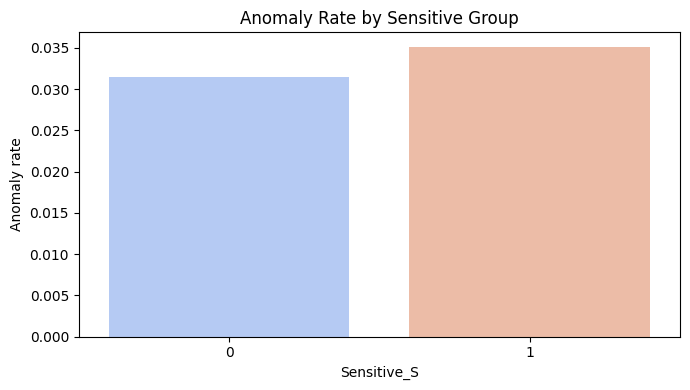

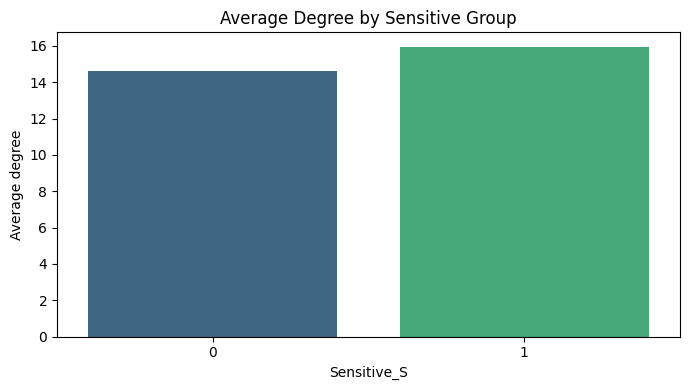

In [ ]:


print("--- Comprehensive EDA Diagnostics ---")

if 'data' not in globals():
    raise RuntimeError("data is not available. Run the loading cell first.")

# Build a compact analysis frame from graph-level tensors.
degree_values = degree(data.edge_index[0], data.num_nodes).detach().cpu().numpy()
df_eda = pd.DataFrame({
    'Sensitive_S': data.s.detach().cpu().numpy(),
    'Label_Y': data.y.detach().cpu().numpy(),
    'Degree': degree_values,
})

if hasattr(data, 'x') and data.x is not None:
    feature_count = min(20, data.x.shape[1])
    feature_matrix = data.x[:, :feature_count].detach().cpu().numpy()
    for feature_idx in range(feature_count):
        df_eda[f'X_{feature_idx}'] = feature_matrix[:, feature_idx]

# 1) Data quality and group balance
print("\n[1] Data quality / group balance")
missing_features = int(torch.isnan(data.x).sum().item()) if hasattr(data, 'x') and data.x is not None else 0
print(f"Missing values in node features: {missing_features}")
print(df_eda[['Sensitive_S', 'Label_Y', 'Degree']].describe(include='all').round(3))

balance_table = (
    df_eda.groupby('Sensitive_S')
    .agg(nodes=('Label_Y', 'size'), anomaly_rate=('Label_Y', 'mean'), avg_degree=('Degree', 'mean'))
    .reset_index()
)
print("\nGroup summary:")
print(balance_table.round(4).to_string(index=False))

plt.figure(figsize=(7, 4))
sns.barplot(data=balance_table, x='Sensitive_S', y='anomaly_rate', palette='coolwarm')
plt.title('Anomaly Rate by Sensitive Group')
plt.xlabel('Sensitive_S')
plt.ylabel('Anomaly rate')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
sns.barplot(data=balance_table, x='Sensitive_S', y='avg_degree', palette='viridis')
plt.title('Average Degree by Sensitive Group')
plt.xlabel('Sensitive_S')
plt.ylabel('Average degree')
plt.tight_layout()
plt.show()



[2] Feature separation checks
Top features by KS distance between sensitive groups:
 feature  ks_stat  p_value
       0  1.00000      0.0
       4  0.28824      0.0
       7  0.23052      0.0
       6  0.22633      0.0
       1  0.22269      0.0
       8  0.20630      0.0
      11  0.19264      0.0
       2  0.18572      0.0


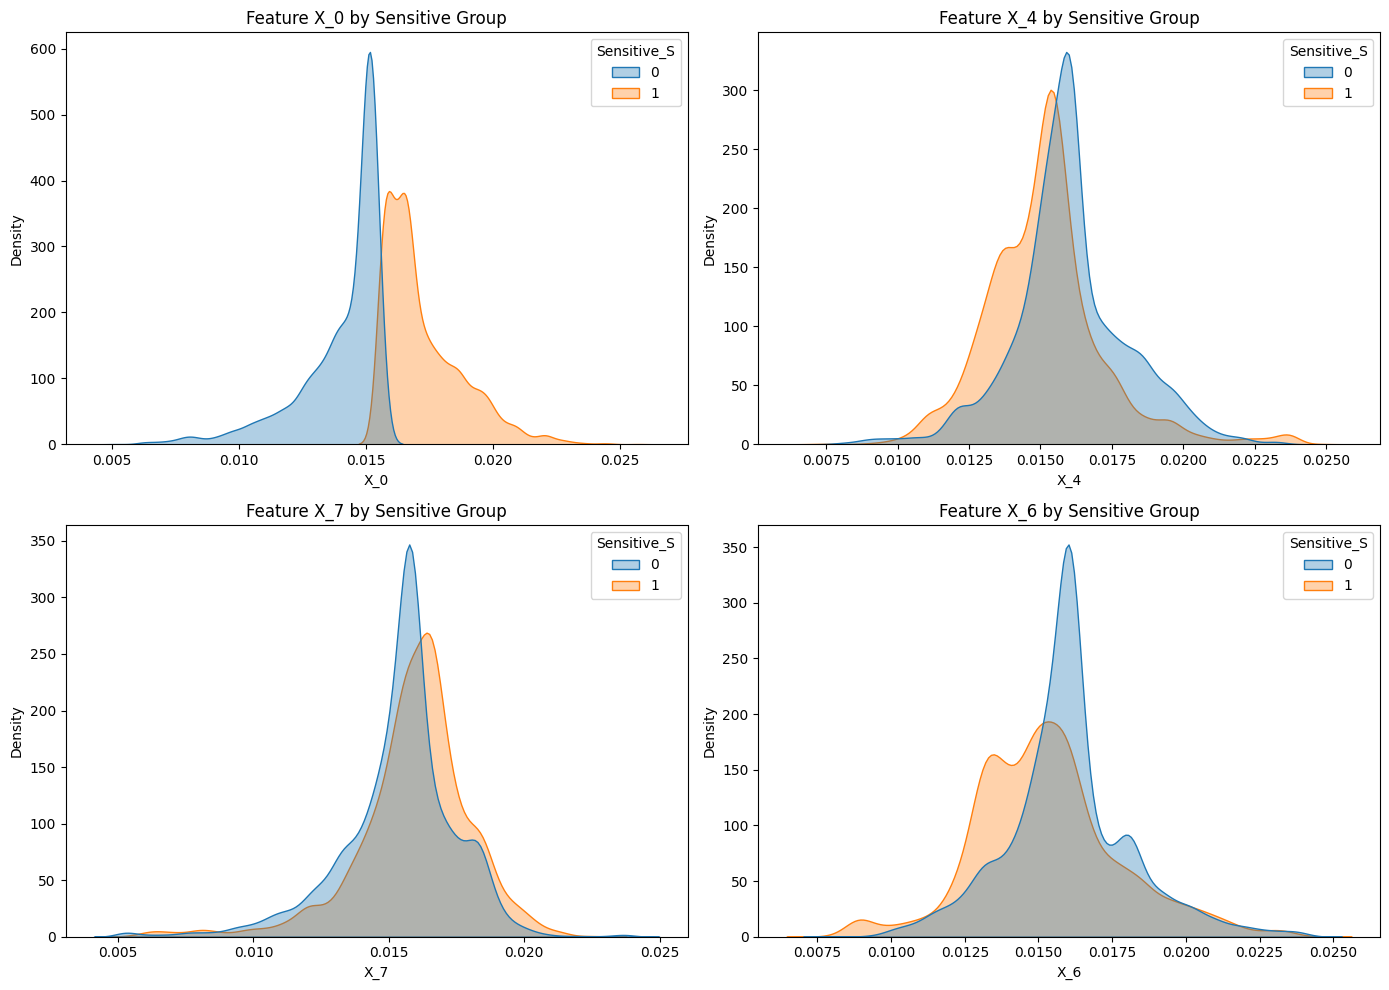

In [ ]:

# 2) Feature separation: KS test and distribution plots
print("\n[2] Feature separation checks")
if hasattr(data, 'x') and data.x is not None:
    ks_rows = []
    s_cpu = df_eda['Sensitive_S'].to_numpy()
    for feature_idx in range(feature_count):
        values_0 = df_eda.loc[s_cpu == 0, f'X_{feature_idx}'].to_numpy()
        values_1 = df_eda.loc[s_cpu == 1, f'X_{feature_idx}'].to_numpy()
        if len(values_0) > 0 and len(values_1) > 0:
            stat, p_value = ks_2samp(values_0, values_1)
            ks_rows.append((feature_idx, stat, p_value))

    ks_df = pd.DataFrame(ks_rows, columns=['feature', 'ks_stat', 'p_value']).sort_values('ks_stat', ascending=False)
    print("Top features by KS distance between sensitive groups:")
    print(ks_df.head(8).round(5).to_string(index=False))

    top_features = ks_df.head(4)['feature'].tolist() if not ks_df.empty else []
    if top_features:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        axes = axes.ravel()
        for ax, feature_idx in zip(axes, top_features):
            sns.kdeplot(data=df_eda, x=f'X_{feature_idx}', hue='Sensitive_S', fill=True, common_norm=False, alpha=0.35, ax=ax)
            ax.set_title(f'Feature X_{feature_idx} by Sensitive Group')
        for ax in axes[len(top_features):]:
            ax.axis('off')
        plt.tight_layout()
        plt.show()




[3] PCA visualization


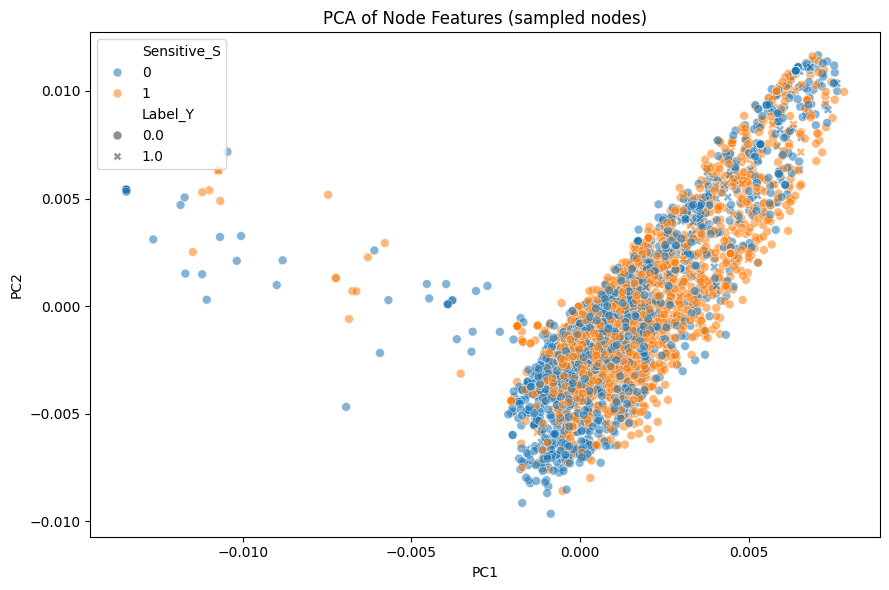

In [ ]:
# 3) PCA view of sampled nodes
print("\n[3] PCA visualization")
rng = np.random.default_rng(42)
if hasattr(data, 'x') and data.x is not None:
    sample_size = min(5000, data.num_nodes)
    strata = list(zip(df_eda['Sensitive_S'].to_numpy(), df_eda['Label_Y'].to_numpy()))
    strata_to_indices = {}
    for idx, key in enumerate(strata):
        strata_to_indices.setdefault(key, []).append(idx)

    sampled_indices = []
    target_per_stratum = max(1, sample_size // max(len(strata_to_indices), 1))
    for indices in strata_to_indices.values():
        take = min(len(indices), target_per_stratum)
        if take > 0:
            sampled_indices.extend(rng.choice(indices, size=take, replace=False).tolist())
    if len(sampled_indices) < sample_size:
        remaining = np.setdiff1d(np.arange(data.num_nodes), np.array(sampled_indices, dtype=int), assume_unique=False)
        if len(remaining) > 0:
            extra = rng.choice(remaining, size=min(sample_size - len(sampled_indices), len(remaining)), replace=False)
            sampled_indices.extend(extra.tolist())

    sampled_indices = np.array(sorted(set(sampled_indices)), dtype=int)
    pca = PCA(n_components=2, random_state=42)
    pca_points = pca.fit_transform(data.x.detach().cpu().numpy()[sampled_indices])
    pca_df = pd.DataFrame({
        'PC1': pca_points[:, 0],
        'PC2': pca_points[:, 1],
        'Sensitive_S': df_eda.iloc[sampled_indices]['Sensitive_S'].to_numpy(),
        'Label_Y': df_eda.iloc[sampled_indices]['Label_Y'].to_numpy(),
    })

    plt.figure(figsize=(9, 6))
    sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Sensitive_S', style='Label_Y', alpha=0.55, s=40)
    plt.title('PCA of Node Features (sampled nodes)')
    plt.tight_layout()
    plt.show()




[4] Model-aware diagnostics
Overall ROC-AUC: 0.5590 | Average Precision: 0.0384


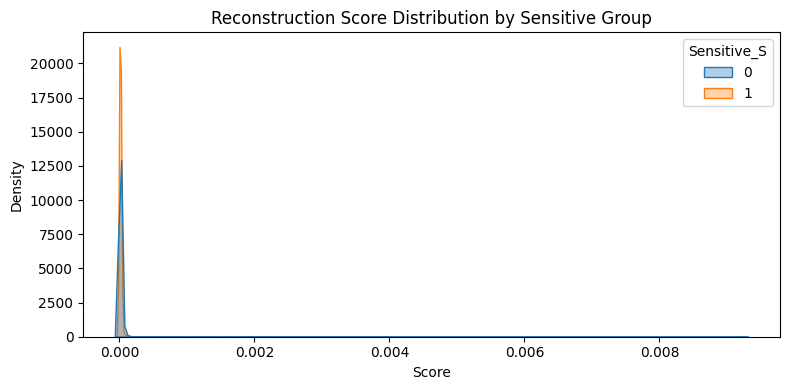

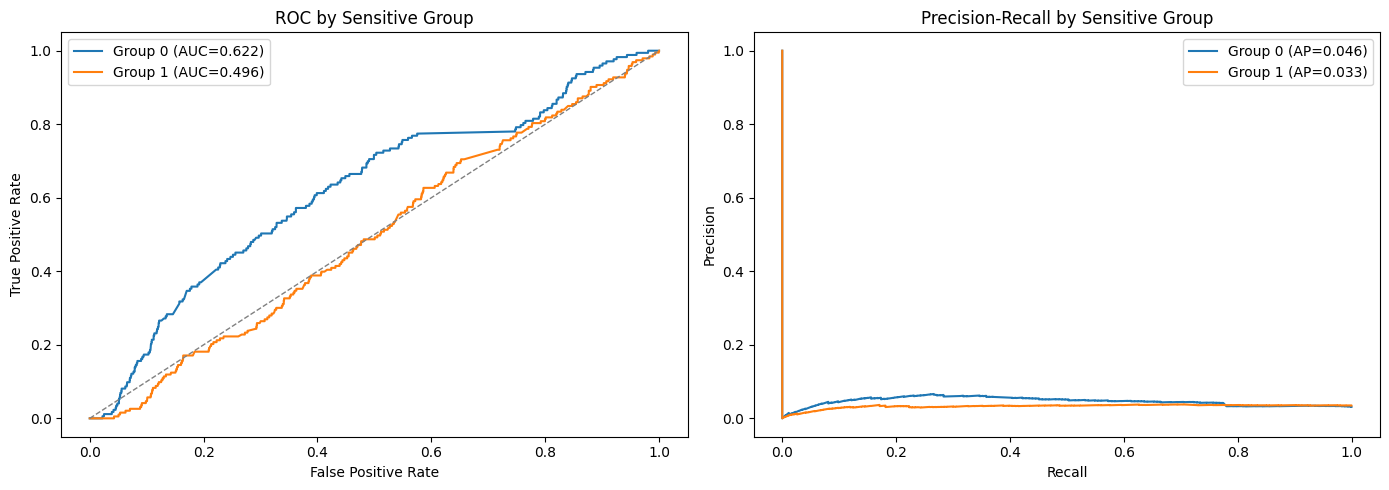

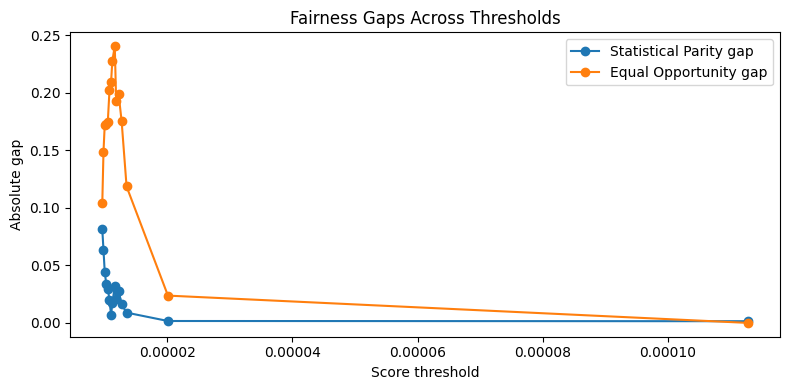

In [ ]:
# 4) Model-aware diagnostics: score distributions and group fairness curves
if 'model' in globals() and hasattr(model, 'forward'):
    print("\n[4] Model-aware diagnostics")
    model.eval()
    with torch.no_grad():
        x_hat, _ = model(data.x, data.edge_index)
        recon_error = torch.mean((x_hat - data.x) ** 2, dim=1)

    scores = recon_error.detach().cpu().numpy()
    df_eda['Score'] = scores
    overall_auc = roc_auc_score(df_eda['Label_Y'], scores)
    overall_ap = average_precision_score(df_eda['Label_Y'], scores)
    print(f"Overall ROC-AUC: {overall_auc:.4f} | Average Precision: {overall_ap:.4f}")

    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=df_eda, x='Score', hue='Sensitive_S', fill=True, common_norm=False, alpha=0.35)
    plt.title('Reconstruction Score Distribution by Sensitive Group')
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for group_value, group_df in df_eda.groupby('Sensitive_S'):
        if group_df['Label_Y'].nunique() > 1:
            fpr, tpr, _ = roc_curve(group_df['Label_Y'], group_df['Score'])
            precision, recall, _ = precision_recall_curve(group_df['Label_Y'], group_df['Score'])
            axes[0].plot(fpr, tpr, label=f'Group {group_value} (AUC={curve_auc(fpr, tpr):.3f})')
            axes[1].plot(recall, precision, label=f'Group {group_value} (AP={average_precision_score(group_df["Label_Y"], group_df["Score"]):.3f})')
    axes[0].plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
    axes[0].set_title('ROC by Sensitive Group')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].legend()
    axes[1].set_title('Precision-Recall by Sensitive Group')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    thresholds = np.percentile(scores, np.linspace(50, 99, 15))
    fairness_rows = []
    y_true = df_eda['Label_Y'].to_numpy()
    s_true = df_eda['Sensitive_S'].to_numpy()
    for threshold in thresholds:
        y_pred = (scores >= threshold).astype(int)
        group_rate_0 = y_pred[s_true == 0].mean() if np.any(s_true == 0) else np.nan
        group_rate_1 = y_pred[s_true == 1].mean() if np.any(s_true == 1) else np.nan
        positives_0 = (y_true == 1) & (s_true == 0)
        positives_1 = (y_true == 1) & (s_true == 1)
        tpr_0 = y_pred[positives_0].mean() if np.any(positives_0) else np.nan
        tpr_1 = y_pred[positives_1].mean() if np.any(positives_1) else np.nan
        fairness_rows.append({
            'threshold': threshold,
            'SP_gap': abs(group_rate_0 - group_rate_1),
            'EO_gap': abs(tpr_0 - tpr_1),
        })

    fairness_df = pd.DataFrame(fairness_rows)
    plt.figure(figsize=(8, 4))
    plt.plot(fairness_df['threshold'], fairness_df['SP_gap'], marker='o', label='Statistical Parity gap')
    plt.plot(fairness_df['threshold'], fairness_df['EO_gap'], marker='o', label='Equal Opportunity gap')
    plt.title('Fairness Gaps Across Thresholds')
    plt.xlabel('Score threshold')
    plt.ylabel('Absolute gap')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Model not found; skipping score-based diagnostics.")
